In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "eia_tx_energy_indicators_monthly.csv"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["period"],
)

df = (
    df.sort_values("period")
    .reset_index(drop=True)
)

df.head()

,period,commercial_customers,commercial_price,commercial_revenue,commercial_sales,industrial_customers,industrial_price,industrial_revenue,industrial_sales,residential_customers,...,commercial_revenue_per_customer_dollars,commercial_reconstructed_price,commercial_price_difference,industrial_sales_per_customer_kwh,industrial_revenue_per_customer_dollars,industrial_reconstructed_price,industrial_price_difference,selected_sector_sales,selected_sector_revenue,selected_sector_customers
0,2015-01-01,1424841.0,8.40,910.06698,10834.88707,97914.0,5.93,502.67896,8481.28780,10236358.0,...,638.714762,8.399414,-0.000586,86619.766326,5133.882387,5.926918,-0.003082,32560.03498,2934.18706,11759113.0
1,2015-02-01,1414177.0,8.50,842.24433,9903.83625,101493.0,5.84,471.33029,8076.96359,10222635.0,...,595.572075,8.504223,0.004223,79581.484339,4643.968451,5.835489,-0.004511,28965.55302,2590.05844,11738305.0
2,2015-03-01,1421352.0,8.49,895.83199,10548.75206,102666.0,5.79,502.20327,8667.54624,10292791.0,...,630.267513,8.492303,0.002303,84424.699901,4891.622056,5.794065,0.004065,30338.81288,2684.11469,11816809.0
3,2015-04-01,1417183.0,7.98,840.64570,10540.04355,104227.0,5.54,491.40865,8870.68519,10302930.0,...,593.180768,7.975733,-0.004267,85109.282528,4714.792232,5.539692,-0.000308,27939.00961,2363.90838,11824340.0
4,2015-05-01,1411987.0,8.21,868.98021,10588.54603,105413.0,5.56,507.11835,9122.37774,10288519.0,...,615.430744,8.206794,-0.003206,86539.399695,4810.776185,5.559059,-0.000941,29234.32130,2522.38691,11805919.0


In [2]:
print(df.shape)
print(df["period"].min(), df["period"].max())
print(df["period"].duplicated().sum())
print(df.isna().sum().loc[lambda x: x > 0])

(136, 54)
2015-01-01 00:00:00 2026-04-01 00:00:00
0
Series([], dtype: int64)


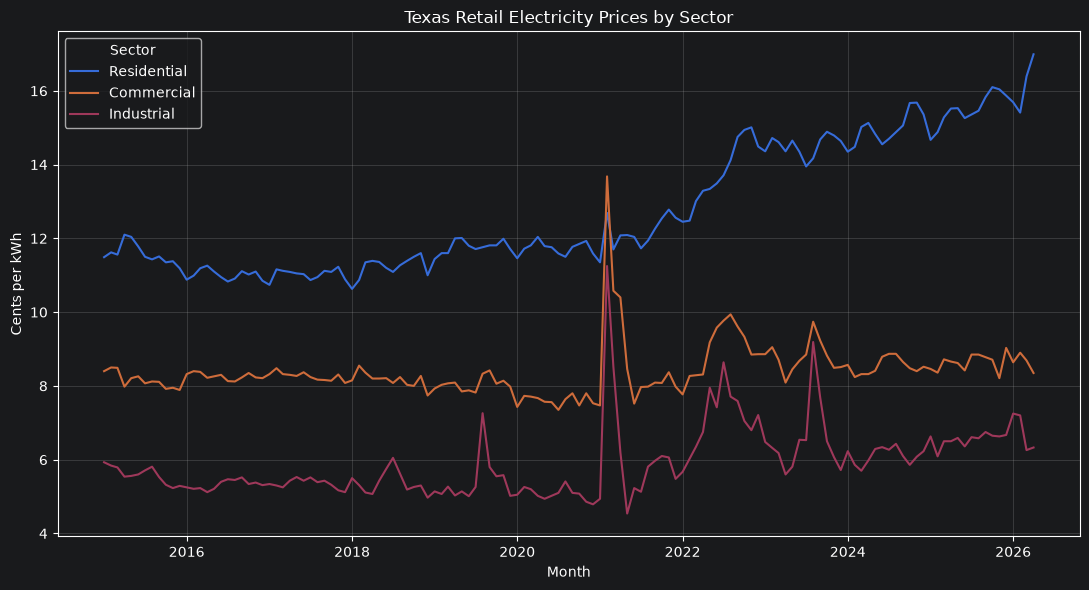

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["residential_price"],
    label="Residential",
)

ax.plot(
    df["period"],
    df["commercial_price"],
    label="Commercial",
)

ax.plot(
    df["period"],
    df["industrial_price"],
    label="Industrial",
)

ax.set_title(
    "Texas Retail Electricity Prices by Sector"
)
ax.set_xlabel("Month")
ax.set_ylabel("Cents per kWh")
ax.legend(title="Sector")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_retail_prices_by_sector.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

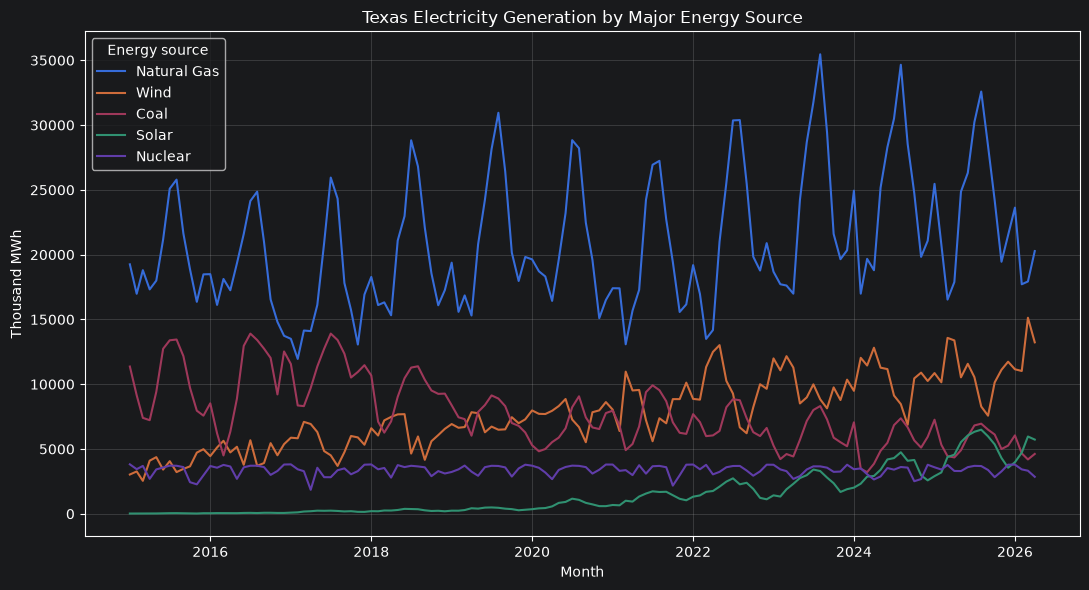

In [4]:
generation_columns = {
    "Natural Gas": "Natural Gas",
    "Wind": "Wind",
    "Coal": "Coal",
    "Solar": "Solar",
    "Nuclear": "Nuclear",
}

fig, ax = plt.subplots(figsize=(11, 6))

for column, label in generation_columns.items():
    ax.plot(
        df["period"],
        df[column],
        label=label,
    )

ax.set_title(
    "Texas Electricity Generation by Major Energy Source"
)
ax.set_xlabel("Month")
ax.set_ylabel("Thousand MWh")
ax.legend(title="Energy source")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_generation_by_major_source.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

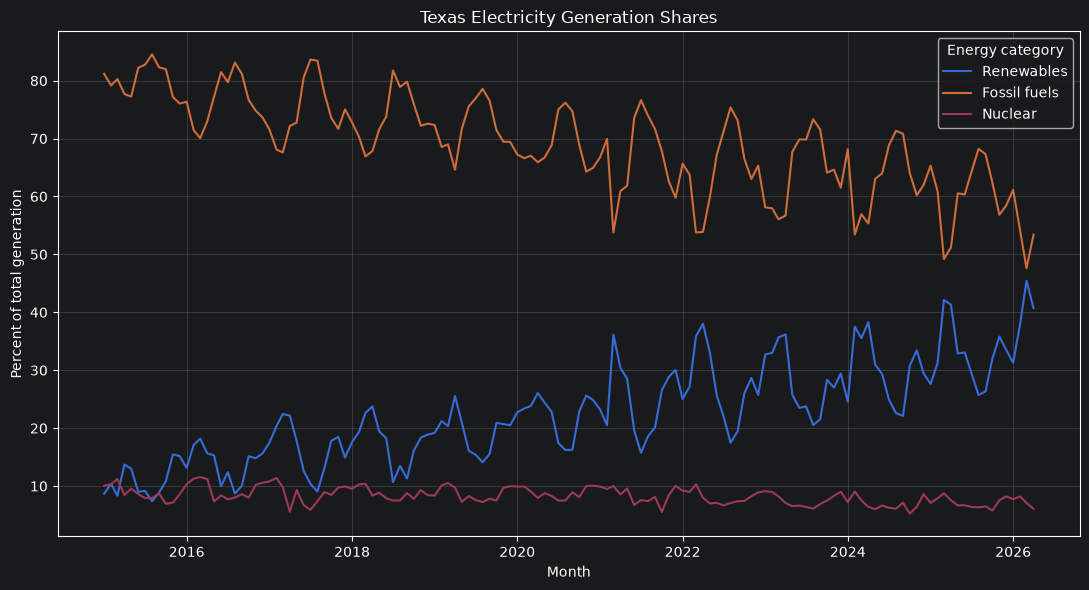

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["renewable_share"] * 100,
    label="Renewables",
)

ax.plot(
    df["period"],
    df["fossil_share"] * 100,
    label="Fossil fuels",
)

ax.plot(
    df["period"],
    df["nuclear_share"] * 100,
    label="Nuclear",
)

ax.set_title(
    "Texas Electricity Generation Shares"
)
ax.set_xlabel("Month")
ax.set_ylabel("Percent of total generation")
ax.legend(title="Energy category")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_generation_shares_broad_categories.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

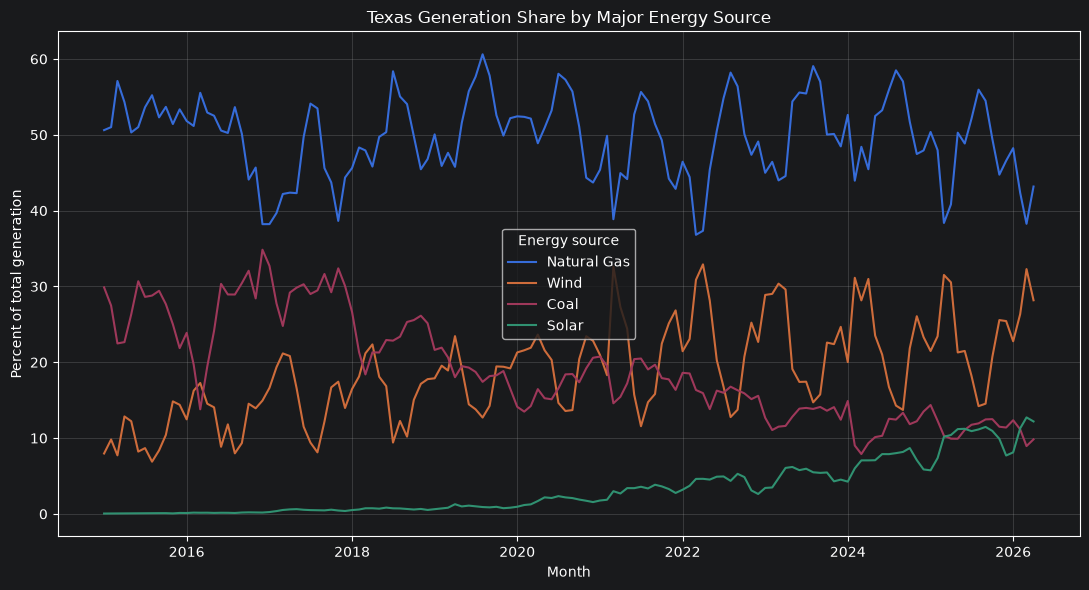

In [6]:
share_columns = {
    "natural_gas_share": "Natural Gas",
    "wind_share": "Wind",
    "coal_share": "Coal",
    "solar_share": "Solar",
}

fig, ax = plt.subplots(figsize=(11, 6))

for column, label in share_columns.items():
    ax.plot(
        df["period"],
        df[column] * 100,
        label=label,
    )

ax.set_title(
    "Texas Generation Share by Major Energy Source"
)
ax.set_xlabel("Month")
ax.set_ylabel("Percent of total generation")
ax.legend(title="Energy source")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_major_fuel_generation_shares.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

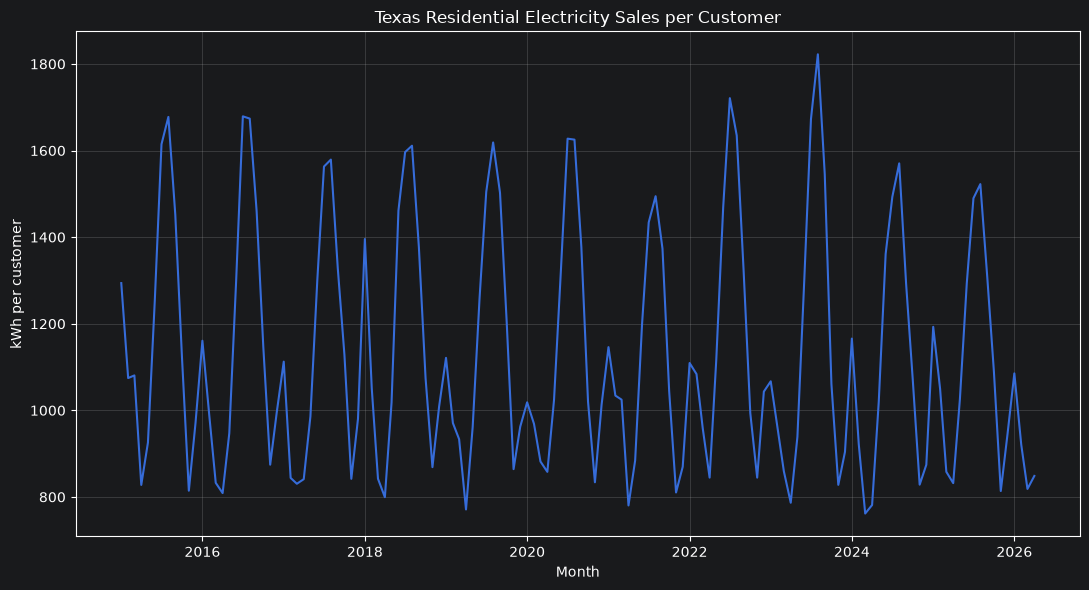

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["period"],
    df["residential_sales_per_customer_kwh"],
)

ax.set_title(
    "Texas Residential Electricity Sales per Customer"
)
ax.set_xlabel("Month")
ax.set_ylabel("kWh per customer")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_residential_sales_per_customer.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()